# Chapter 3: Data Visualization

Pandas provides a number of basic plotting capabilities. Matplotlib however gives you more control over details of the visualisation. The Pandas plot methods return an axes object, which can also be used to modify the visualisation using basic matplotlib commands.

## Import required packages

In [1]:
%matplotlib inline
# The %matplotlib inline is a jupyter notebook specific command that let’s you see the plots in the notbook itself.
import os
import calendar
from pathlib import Path
import numpy as np
import networkx as nx
import pandas as pd
from pandas.plotting import scatter_matrix, parallel_coordinates
import seaborn as sns
from sklearn import preprocessing
#import matplotlib.pylab as plt
import matplotlib.pyplot as plt
# the Pyplot module from Matplotlib package is imported, with an alias plt as a matter of convention.
# pylab combines pyplot with numpy into a single namespace (associate identifiers with objects and implemented "under the hood" as dictionaries). 
# This is convenient for interactive work, 
# but for programming it is recommended that the namespaces be kept separate, e.g.: 
# import numpy as np
# import matplotlib.pyplot as plt
# matplotlib.pyplot is a collection of functions that make matplotlib work like MATLAB.
# PyLab is a procedural interface to the Matplotlib object-oriented plotting library. 
# Matplotlib is the whole package; matplotlib.pyplot is a module in Matplotlib; 
# and PyLab is a module that gets installed alongside Matplotlib.

In [2]:
# Working directory:
#
# We assume that data are kept in the same directory as the notebook. If you keep your 
# data in a different folder, replace the argument of the `Path`
DATA = Path('/Users/min/OneDrive/teaching/DS110/dmba/')
# and then load data using 
#
# pd.read_csv(DATA / ‘filename.csv’)

## Figure 3.1
Load the Amtrak data and convert them to be suitable for time series analysis

In [6]:
Amtrak_df = pd.read_csv(DATA / 'Amtrak.csv')
# squeeze: bool, default False. If the parsed data only contains one column then return a Series. 
# Squeeze will try to reduce the dimension if its possible to reduce

In [8]:
Amtrak_df

,Month,Ridership
0,01/01/1991,1708.917
1,01/02/1991,1620.586
2,01/03/1991,1972.715
3,01/04/1991,1811.665
4,01/05/1991,1974.964
...,...,...
154,01/11/2003,2076.054
155,01/12/2003,2140.677
156,01/01/2004,1831.508
157,01/02/2004,1838.006


In [10]:
Amtrak_df['Date'] = pd.to_datetime(Amtrak_df.Month, format='%d/%m/%Y')
ridership_ts = pd.Series(Amtrak_df.Ridership.values, index=Amtrak_df.Date)

In [12]:
Amtrak_df.Ridership.values

array([1708.917, 1620.586, 1972.715, 1811.665, 1974.964, 1862.356,
       1939.86 , 2013.264, 1595.657, 1724.924, 1675.667, 1813.863,
       1614.827, 1557.088, 1891.223, 1955.981, 1884.714, 1623.042,
       1903.309, 1996.712, 1703.897, 1810.   , 1861.601, 1875.122,
       1705.259, 1618.535, 1836.709, 1957.043, 1917.185, 1882.398,
       1933.009, 1996.167, 1672.841, 1752.827, 1720.377, 1734.292,
       1563.365, 1573.959, 1902.639, 1833.888, 1831.049, 1775.755,
       1867.508, 1906.608, 1685.632, 1778.546, 1775.995, 1783.35 ,
       1548.415, 1496.925, 1798.316, 1732.895, 1772.345, 1761.207,
       1791.655, 1874.82 , 1571.309, 1646.948, 1672.631, 1656.845,
       1381.758, 1360.852, 1558.575, 1608.42 , 1696.696, 1693.183,
       1835.516, 1942.573, 1551.401, 1686.508, 1576.204, 1700.433,
       1396.588, 1371.69 , 1707.522, 1654.604, 1762.903, 1775.8  ,
       1934.219, 2008.055, 1615.924, 1773.91 , 1732.368, 1796.626,
       1570.33 , 1412.691, 1754.641, 1824.932, 1843.289, 1825.

In [14]:
Amtrak_df.Date

0     1991-01-01
1     1991-02-01
2     1991-03-01
3     1991-04-01
4     1991-05-01
         ...    
154   2003-11-01
155   2003-12-01
156   2004-01-01
157   2004-02-01
158   2004-03-01
Name: Date, Length: 159, dtype: datetime64[ns]

In [16]:
ridership_ts

Date
1991-01-01    1708.917
1991-02-01    1620.586
1991-03-01    1972.715
1991-04-01    1811.665
1991-05-01    1974.964
                ...   
2003-11-01    2076.054
2003-12-01    2140.677
2004-01-01    1831.508
2004-02-01    1838.006
2004-03-01    2132.446
Length: 159, dtype: float64

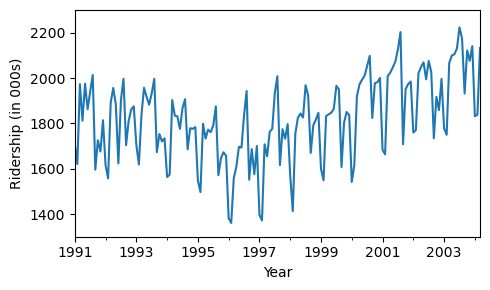

In [18]:
ridership_ts.plot(ylim=[1300, 2300], legend=False, figsize=[5, 3])
plt.xlabel('Year')  # set x-axis label
plt.ylabel('Ridership (in 000s)')  # set y-axis label
plt.tight_layout() # adjust subplot params so that subplots are nicely fit in the figure
plt.show() # starts an event loop, looks for all currently active figure objects, and opens one or more interactive windows that display your figure or figures. 

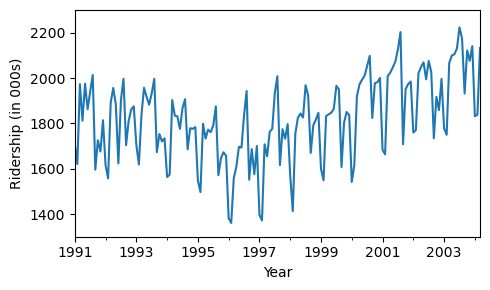

In [19]:
# save the figure (delete plt.show() first): plt.savefig("amtrak.png", transparent=True, dpi=120)
ridership_ts.plot(ylim=[1300, 2300], legend=False, figsize=[5, 3])
plt.xlabel('Year')  # set x-axis label
plt.ylabel('Ridership (in 000s)')  # set y-axis label
plt.tight_layout() # adjust subplot params so that subplots are nicely fit in the figure
plt.savefig(DATA / "amtrak.png", transparent=True, dpi=120)

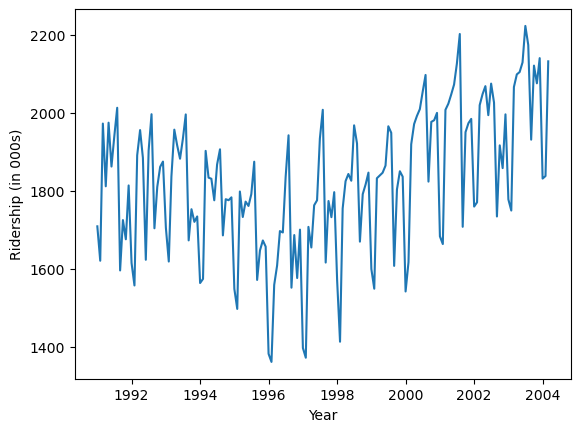

In [21]:
# alternative plot with matplotlib
plt.plot(ridership_ts.index, ridership_ts)
plt.xlabel('Year')  # set x-axis label
plt.ylabel('Ridership (in 000s)')  # set y-axis label
plt.show()

In [24]:
ridership_ts

Date
1991-01-01    1708.917
1991-02-01    1620.586
1991-03-01    1972.715
1991-04-01    1811.665
1991-05-01    1974.964
                ...   
2003-11-01    2076.054
2003-12-01    2140.677
2004-01-01    1831.508
2004-02-01    1838.006
2004-03-01    2132.446
Length: 159, dtype: float64

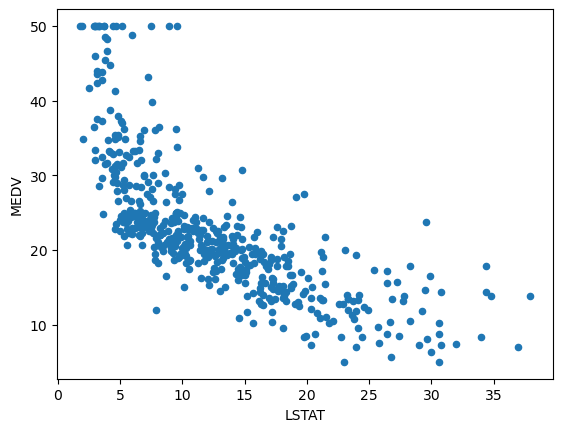

In [26]:
housing_df = pd.read_csv(DATA / 'BostonHousing.csv')
# rename CAT. MEDV column for easier data handling
housing_df = housing_df.rename(columns={'CAT. MEDV': 'CAT_MEDV'})
# Pandas plot
housing_df.plot.scatter(x='LSTAT', y='MEDV', legend=False)
plt.show()

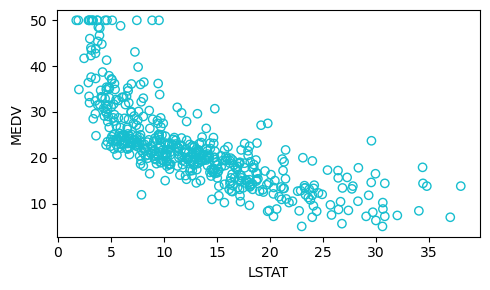

In [28]:
# Matplotlib plot
# Create 2 objects: the figure and the axes (subplots) inside the figure. 
# Similar to Matlab. See Section 4 of the matplotlib tutorial.
fig, ax = plt.subplots()
fig.set_size_inches(5, 3)
# Set the color of the points in the scatterplot and draw as open circles.
ax.scatter(housing_df.LSTAT, housing_df.MEDV, color='C9', facecolor='none')
plt.xlabel('LSTAT')
plt.ylabel('MEDV')
plt.tight_layout()
plt.show()

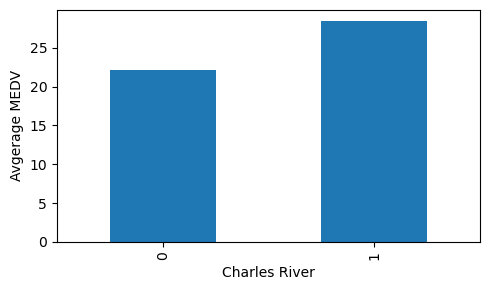

In [30]:
# Pandas plot
ax = housing_df.groupby('CHAS').mean().MEDV.plot(kind='bar', figsize=[5, 3])
ax.set_ylabel('Avgerage MEDV')
ax.set_xlabel('Charles River')
plt.tight_layout()
plt.show()

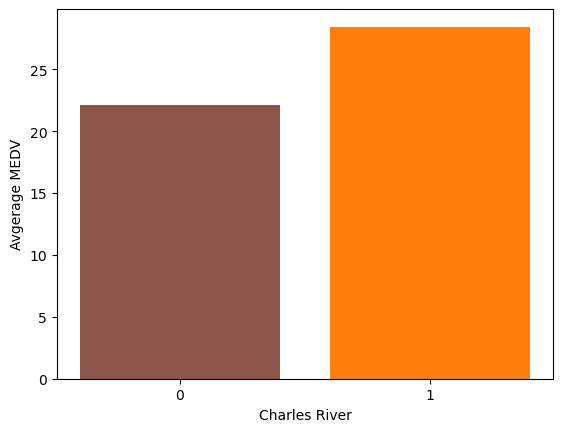

In [32]:
# Matplotlib plot
dataForPlot = housing_df.groupby('CHAS').mean().MEDV
fig, ax = plt.subplots()
ax.bar(dataForPlot.index, dataForPlot, color=['C5', 'C1'])
ax.set_xticks([0, 1])
ax.set_xlabel('Charles River')
ax.set_ylabel('Avgerage MEDV')
plt.show()

In [34]:
dataForPlot

CHAS
0    22.093843
1    28.440000
Name: MEDV, dtype: float64

In [36]:
dataForPlot.index

Int64Index([0, 1], dtype='int64', name='CHAS')

In [38]:
housing_df.groupby('CHAS').mean()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV,CAT_MEDV
CHAS,,,,,,,,,,,,,
0,3.744447,11.634820,11.019193,0.551817,6.267174,67.911677,3.851915,9.566879,409.870488,18.527176,12.757941,22.093843,0.154989
1,1.851670,7.714286,12.719143,0.593426,6.519600,77.500000,3.029709,9.314286,386.257143,17.491429,11.241714,28.440000,0.314286


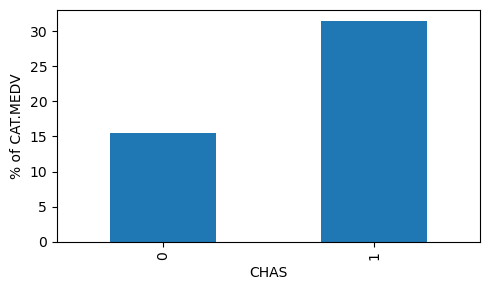

In [40]:
# Pandas version not using matplotlib
dataForPlot = housing_df.groupby('CHAS').mean()['CAT_MEDV'] * 100 # find the proportion of 0, 1 variable CAT_MEDV by findng the mean
ax = dataForPlot.plot(kind='bar', figsize=[5, 3])
ax.set_ylabel('% of CAT.MEDV')
plt.tight_layout()
plt.show()

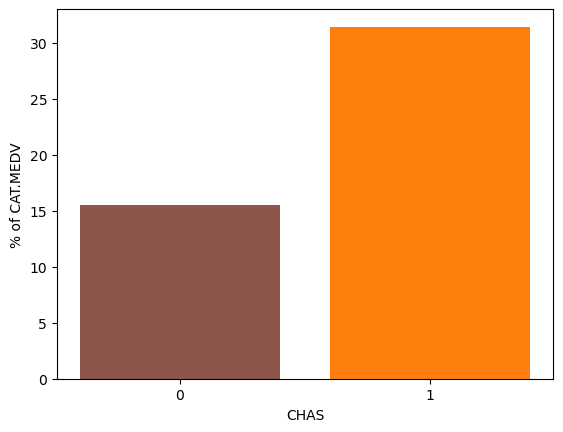

In [42]:
# matplotlib plot
fig, ax = plt.subplots()
ax.bar(dataForPlot.index, dataForPlot, color=['C5', 'C1'])
ax.set_xticks([0, 1])
ax.set_xlabel('CHAS')
ax.set_ylabel('% of CAT.MEDV')
plt.show()

## Figure 3.2
Histogram of MEDV

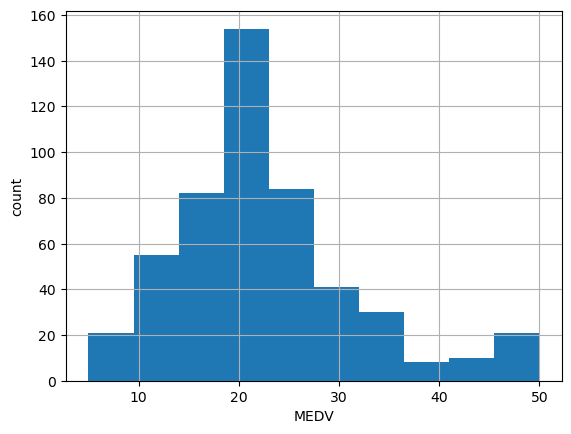

In [45]:
# Pandas plot
ax = housing_df.MEDV.hist()
ax.set_xlabel('MEDV')
ax.set_ylabel('count')
plt.show()

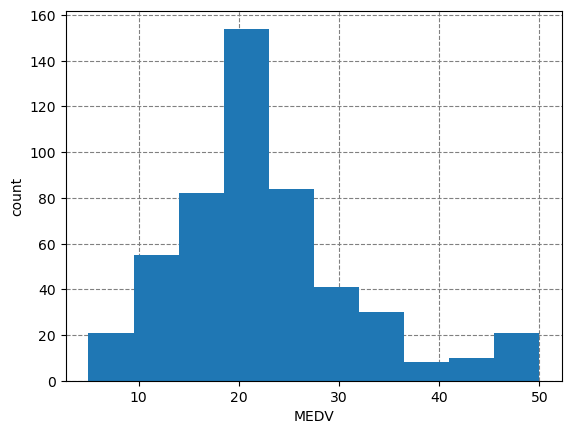

In [47]:
# Matplotlib plot
fig, ax = plt.subplots()
ax.hist(housing_df.MEDV)
ax.set_axisbelow(True)  # Show the grid lines behind the histogram
ax.grid(which='major', color='grey', linestyle='--') # which{'major', 'minor', 'both'}, optional, The grid lines to apply the changes on.
ax.set_xlabel('MEDV')
ax.set_ylabel('count')
plt.show()

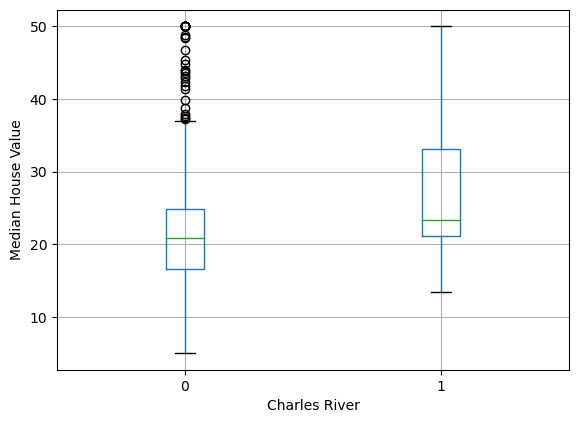

In [49]:
# Pandas plot
# Side by side box plots
ax = housing_df.boxplot(column='MEDV', by='CHAS')
ax.set_ylabel('Median House Value')
ax.set_xlabel('Charles River')
plt.suptitle('')  # Suppress the titles
plt.title('')
plt.show()

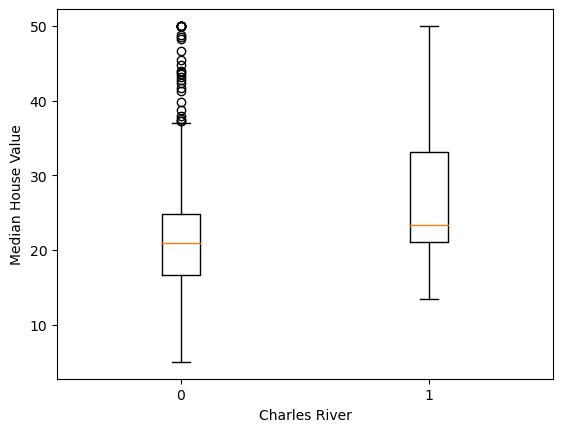

In [51]:
# Matplotlib plot
dataForPlot = [list(housing_df[housing_df.CHAS==0].MEDV), list(housing_df[housing_df.CHAS==1].MEDV)]
fig, ax = plt.subplots()
ax.boxplot(dataForPlot)
ax.set_xticks([1, 2])
# [1, 2] creates a tick at 1,2. 
ax.set_xticklabels([0, 1])
# place "0" at tick "1" and "1" at tick "2" 
ax.set_xlabel('Charles River')
ax.set_ylabel('Median House Value')
plt.show()

In [53]:
dataForPlot

[[24.0,
  21.6,
  34.7,
  33.4,
  36.2,
  28.7,
  22.9,
  27.1,
  16.5,
  18.9,
  15.0,
  18.9,
  21.7,
  20.4,
  18.2,
  19.9,
  23.1,
  17.5,
  20.2,
  18.2,
  13.6,
  19.6,
  15.2,
  14.5,
  15.6,
  13.9,
  16.6,
  14.8,
  18.4,
  21.0,
  12.7,
  14.5,
  13.2,
  13.1,
  13.5,
  18.9,
  20.0,
  21.0,
  24.7,
  30.8,
  34.9,
  26.6,
  25.3,
  24.7,
  21.2,
  19.3,
  20.0,
  16.6,
  14.4,
  19.4,
  19.7,
  20.5,
  25.0,
  23.4,
  18.9,
  35.4,
  24.7,
  31.6,
  23.3,
  19.6,
  18.7,
  16.0,
  22.2,
  25.0,
  33.0,
  23.5,
  19.4,
  22.0,
  17.4,
  20.9,
  24.2,
  21.7,
  22.8,
  23.4,
  24.1,
  21.4,
  20.0,
  20.8,
  21.2,
  20.3,
  28.0,
  23.9,
  24.8,
  22.9,
  23.9,
  26.6,
  22.5,
  22.2,
  23.6,
  28.7,
  22.6,
  22.0,
  22.9,
  25.0,
  20.6,
  28.4,
  21.4,
  38.7,
  43.8,
  33.2,
  27.5,
  26.5,
  18.6,
  19.3,
  20.1,
  19.5,
  19.5,
  20.4,
  19.8,
  19.4,
  21.7,
  22.8,
  18.8,
  18.7,
  18.5,
  18.3,
  21.2,
  19.2,
  20.4,
  19.3,
  22.0,
  20.3,
  20.5,
  17.3,
  18.8,


## Figure 3.3
Side by side boxplots

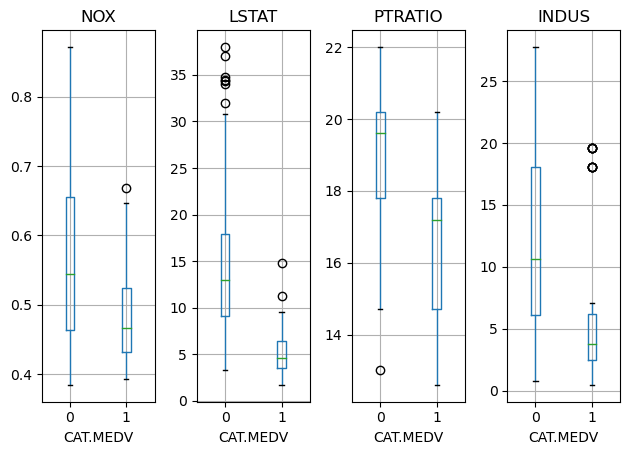

In [56]:
fig, axes = plt.subplots(nrows=1, ncols=4)
housing_df.boxplot(column='NOX', by='CAT_MEDV', ax=axes[0])
housing_df.boxplot(column='LSTAT', by='CAT_MEDV', ax=axes[1])
housing_df.boxplot(column='PTRATIO', by='CAT_MEDV', ax=axes[2])
housing_df.boxplot(column='INDUS', by='CAT_MEDV', ax=axes[3])
for ax in axes:
    ax.set_xlabel('CAT.MEDV')
plt.suptitle('')  # Suppress the overall title
plt.tight_layout()  # Increase the separation between the plots
plt.show()

## Figure 3.4

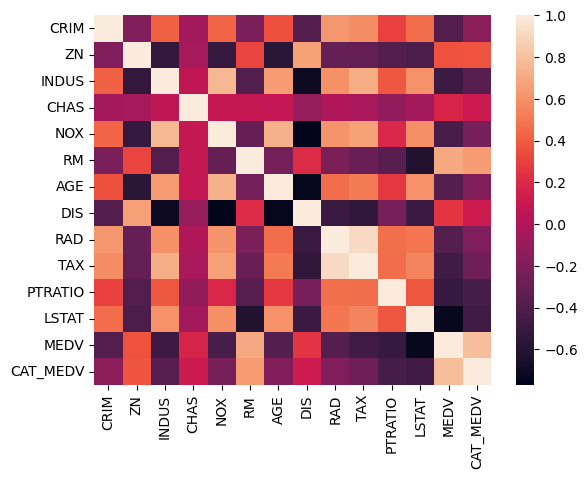

In [59]:
corr = housing_df.corr()
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns)
plt.show()

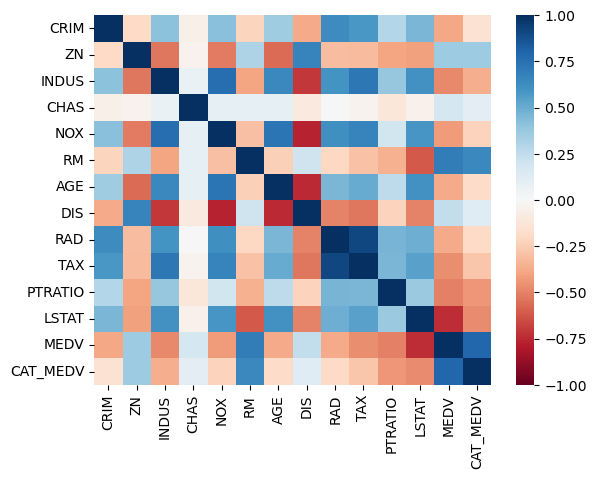

In [61]:
# Change the colormap to a divergent scale and fix the range of the colormap
# cmap: matplotlib colormap name or object, or list of colors, optional
#       The mapping from data values to color space. If not provided, the default will depend on whether center is set.
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns, vmin=-1, vmax=1, cmap="RdBu")
plt.show()

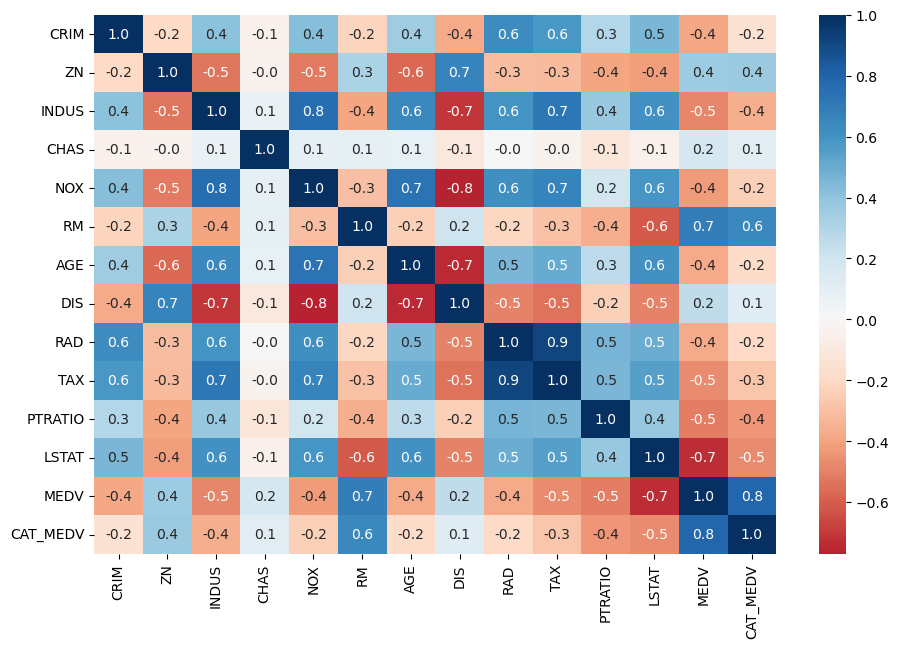

In [63]:
# Include information about values
# annot: bool or rectangular dataset, optional
#        If True, write the data value in each cell. If an array-like with the same shape as data, then use this to annotate the heatmap instead of the data. 
#        Note that DataFrames will match on position, not index.
# fmt: str, optional, String formatting code to use when adding annotations. Here one decimal correlation coefficient.
fig, ax = plt.subplots()
fig.set_size_inches(11, 7)
sns.heatmap(corr, annot=True, fmt=".1f", cmap="RdBu", center=0, ax=ax)
plt.show()

## Figure 3.5
A heatmap can also be used to visualize missing values. Here, we use a sample of the NYPD Motor Vehicle Collisions Dataset. (https://data.cityofnewyork.us/Public-Safety/NYPD-Motor-Vehicle-Collisions/h9gi-nx95)

In [66]:
# df = pd.read_csv('NYPD_Motor_Vehicle_Collisions.csv')
# df = df.sample(1000)
# # df.head()
# df.to_csv('NYPD_Motor_Vehicle_Collisions_1000.csv', index=False)

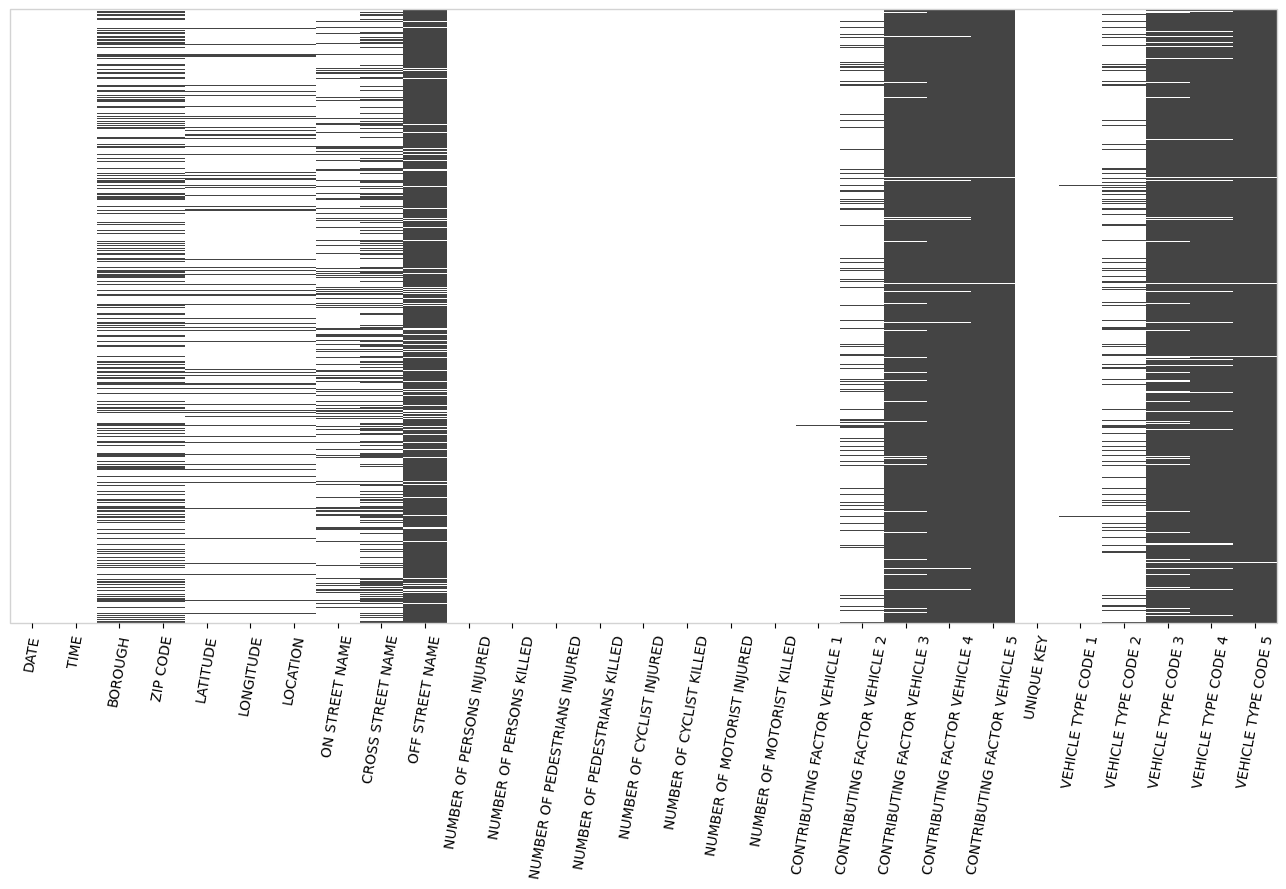

In [68]:
# # Create a dataframe with missing values
# np.random.seed(12345)
# df = pd.DataFrame(np.random.randint(50, size=(100, 10)))
# df.where(df!=max(df), np.nan, inplace=True)

# # Given a dataframe df create a copy of the array that is 0 if a field contains a value and 1 for NaN
# naInfo = np.zeros(df.shape)
# naInfo[df.isna().values] = 1
# ax = sns.heatmap(naInfo, vmin=0, vmax=1, cmap=["white", "red"], cbar=False)

df = pd.read_csv(DATA / 'NYPD_Motor_Vehicle_Collisions_1000.csv').sort_values(['DATE'])

# Given a dataframe df create a copy of the array that is 0 if a field contains a value 
# and 1 for NaN
naInfo = np.zeros(df.shape)
naInfo[df.isna().values] = 1
naInfo = pd.DataFrame(naInfo, columns=df.columns)

fig, ax = plt.subplots()
fig.set_size_inches(13, 9)
ax = sns.heatmap(naInfo, vmin=0, vmax=1, cmap=["white", "#444444"], cbar=False, ax=ax)
# cbar - Whether to draw a colorbar.
# ax: matplotlib Axes, optional. Axes in which to draw the plot, otherwise use the currently-active Axes.
# see https://seaborn.pydata.org/generated/seaborn.heatmap.html

ax.set_yticks([])
# class matplotlib.patches.Rectangle(xy, width, height, angle=0.0, **kwargs)
# see https://matplotlib.org/api/_as_gen/matplotlib.patches.Rectangle.html
# Create a rectangle defined via an anchor point xy and its width and height
# xy(float, float) - The anchor point.
# width: float, Rectangle width.
# height: float, Rectangle height.
# angle: float, default: 0
# Rotation in degrees anti-clockwise about xy.

rect = plt.Rectangle((0, 0), naInfo.shape[1], naInfo.shape[0], linewidth=1, 
                     edgecolor='lightgrey',facecolor='none')
# Add a Patch to the axes' patches; return the patch.
rect = ax.add_patch(rect)
rect.set_clip_on(False)
# Set whether the artist uses clipping. When False artists will be visible outside of the axes which can lead to unexpected results.
plt.xticks(rotation=80)
plt.tight_layout()
plt.show()

In [70]:
df.shape

(1000, 29)

## Figure 3.6

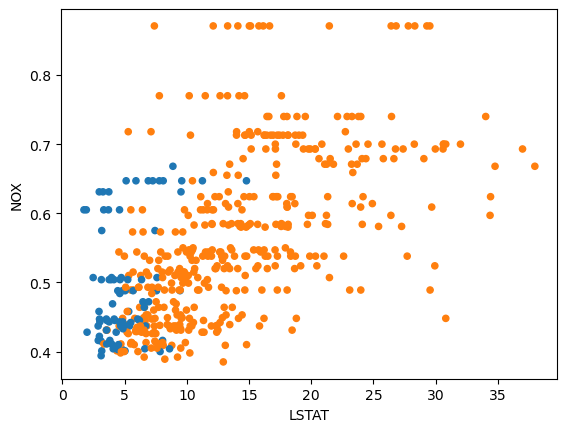

In [73]:
# Color (c=) the points by the value of CAT.MEDV
housing_df.plot.scatter(x='LSTAT', y='NOX', c=['C0' if c == 1 else 'C1' for c in housing_df.CAT_MEDV])
plt.show()

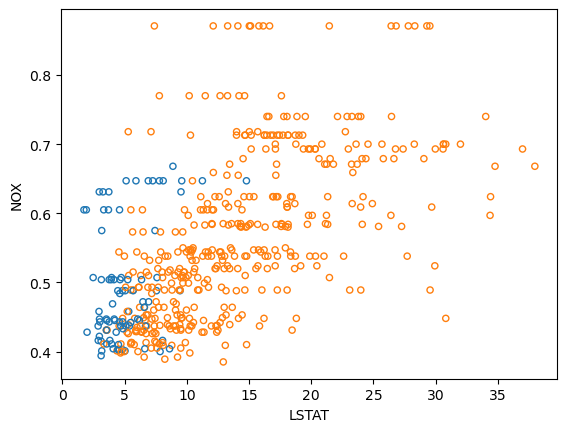

In [75]:
# Change the rendering of the points to open circles by controlling the color
# edgecolors : {'face', 'none', None} or color or sequence of color, optional.
#    The edge color of the marker. Possible values:
#        'face': The edge color will always be the same as the face color.
#       'none': No patch boundary will be drawn.
#        A Matplotlib color or sequence of color.
#    Defaults to None, in which case it takes the value of rcParams["scatter.edgecolors"] = 'face'.
#    For non-filled markers, the edgecolors kwarg is ignored and forced to 'face' internally.

housing_df.plot.scatter(x='LSTAT', y='NOX', color='none',
                        edgecolor=['C0' if c == 1 else 'C1' for c in housing_df.CAT_MEDV])
plt.show()

If the data points for `CAT_MEDV` of 1 should be emphasized, it's useful to draw them separately.

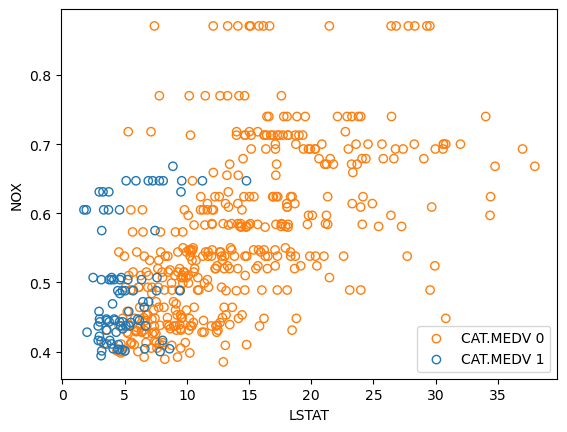

In [78]:
# Plot first the data points for CAT.MEDV of 0 and then of 1
# Setting color to 'none' gives open circles
_, ax = plt.subplots()
for catValue, color in (0, 'C1'), (1, 'C0'):
    subset_df = housing_df[housing_df.CAT_MEDV == catValue]
    ax.scatter(subset_df.LSTAT, subset_df.NOX, color='none', edgecolor=color)
ax.set_xlabel('LSTAT')
ax.set_ylabel('NOX')
ax.legend(["CAT.MEDV 0", "CAT.MEDV 1"])
plt.show()

## Panel plots

Compute mean MEDV per RAD and CHAS and create two bar charts for each value of RAD

In [81]:
dataForPlot_df = housing_df.groupby(['CHAS','RAD']).mean()['MEDV']
# We determine all possible RAD values to use as ticks
ticks = set(housing_df.RAD) 
# ticks = {1, 2, 3, 4, 5, 6, 7, 8, 24} here
# range(2) == [0, 1]
# Ticks are the values used to show specific points on the coordinate axis. It can be a number or a string. 
ticks

{1, 2, 3, 4, 5, 6, 7, 8, 24}

In [83]:
dataForPlot_df

CHAS  RAD
0     1      23.015789
      2      26.833333
      3      27.927778
      4      21.040196
      5      25.521154
      6      20.976923
      7      27.105882
      8      31.505263
      24     15.438710
1     1      50.000000
      3      27.950000
      4      25.812500
      5      27.463636
      8      26.000000
      24     31.362500
Name: MEDV, dtype: float64

In [85]:
for i in range(2):
    for t in ticks.difference(dataForPlot_df[i].index):
# set parts of dataForPlot_df to 0 
        dataForPlot_df.loc[(i, t)] = 0
# reorder to rows, so that the index is sorted
dataForPlot_df = dataForPlot_df[sorted(dataForPlot_df.index)]
dataForPlot_df

CHAS  RAD
0     1      23.015789
      2      26.833333
      3      27.927778
      4      21.040196
      5      25.521154
      6      20.976923
      7      27.105882
      8      31.505263
      24     15.438710
1     1      50.000000
      2       0.000000
      3      27.950000
      4      25.812500
      5      27.463636
      6       0.000000
      7       0.000000
      8      26.000000
      24     31.362500
Name: MEDV, dtype: float64

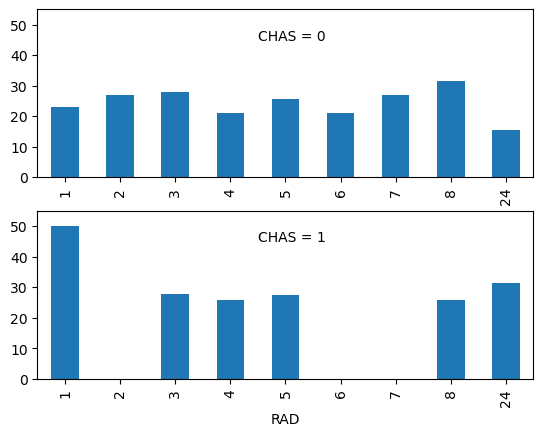

In [87]:
# Determine a common range for the y axis
yRange = [0, max(dataForPlot_df) * 1.1] 

fig, axes = plt.subplots(nrows=2, ncols=1)
dataForPlot_df[0].plot.bar(x='RAD', ax=axes[0], ylim=yRange)
dataForPlot_df[1].plot.bar(x='RAD', ax=axes[1], ylim=yRange)
axes[0].annotate('CHAS = 0', xy=(3.5, 45))
axes[1].annotate('CHAS = 1', xy=(3.5, 45))
plt.show()

In [89]:
dataForPlot_df.loc[(1,8)]

26.0

In [91]:
dataForPlot_df.index 

MultiIndex([(0,  1),
            (0,  2),
            (0,  3),
            (0,  4),
            (0,  5),
            (0,  6),
            (0,  7),
            (0,  8),
            (0, 24),
            (1,  1),
            (1,  2),
            (1,  3),
            (1,  4),
            (1,  5),
            (1,  6),
            (1,  7),
            (1,  8),
            (1, 24)],
           names=['CHAS', 'RAD'])

## Figure 3.7
Scatterplot matrix

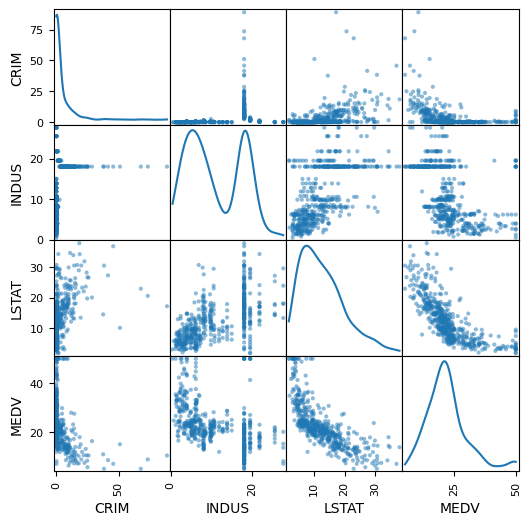

In [94]:
_ = scatter_matrix(housing_df[['CRIM', 'INDUS', 'LSTAT', 'MEDV']], figsize=(6, 6), diagonal='kde')
# In this format, when you got to a diagonal, you would see a plot of a column against itself. 
# Since this would always be a straight line, Pandas decides it can give you more useful information, 
# and plots the probability density plot (distribution) of just that column of data.

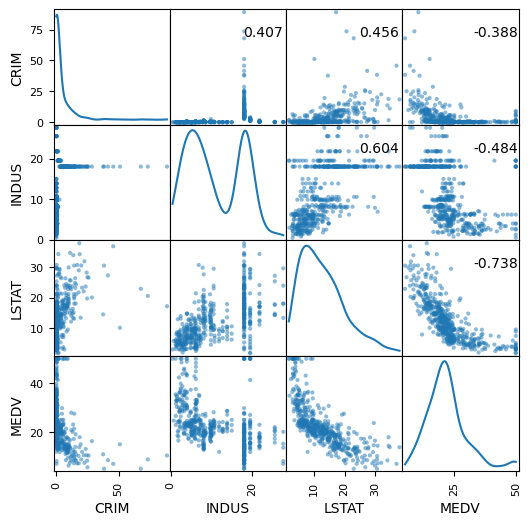

In [96]:
# Add the correlation coefficient to the scatterplots above the diagonal
df = housing_df[['CRIM', 'INDUS', 'LSTAT', 'MEDV']]
axes = scatter_matrix(df, alpha=0.5, figsize=(6, 6), diagonal='kde')
# alpha: float, optional, Amount of transparency applied.
corr = df.corr().values
# Built-in function zip enables iterating over multiple iterables of data at the same time.
# The function receives as arguments any number of iterables and returns an iterator that
# produces tuples containing the elements at the same index in each.
for i, j in zip(*plt.np.triu_indices_from(axes, k=1)):
    axes[i, j].annotate("%.3f" %corr[i,j], (0.8, 0.8), xycoords='axes fraction', ha='center', va='center')
# numpy.triu_indices_from(arr, k=0)[source]   Return the indices for the upper-triangle of arr.
# Parameters: arr: ndarray, shape(N, N), The indices will be valid for square arrays.
# k: int, optional, Diagonal offset (see triu for details).
# Returns triu_indices_fromtuple, shape(2) of ndarray, shape(N), Indices for the upper-triangle of arr.
# xycoords='axes fraction': Fraction of axes from lower left. See https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.axes.Axes.annotate.html
# ha: horizontalalignment
# va: verticalalignment
plt.show()

## Figure 3.8

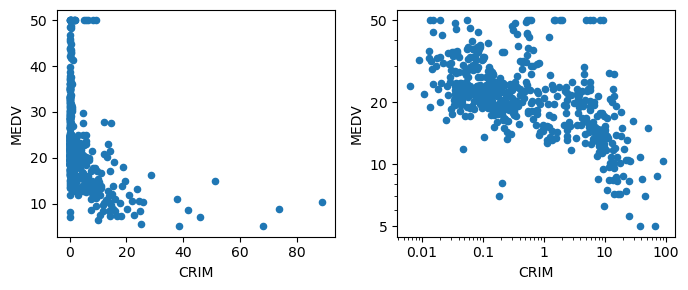

In [99]:
# Avoid the use of scientific notation for the log axis
plt.rcParams['axes.formatter.min_exponent'] = 4
# Matplotlib rcParams
# Dynamic rc settings
# You can also dynamically change the default rc settings in a python script 
# or interactively from the python shell. All of the rc settings are stored in 
# a dictionary-like variable called matplotlib.rcParams, which is global 
# to the matplotlib package. rcParams can be modified directly
# see https://matplotlib.org/api/matplotlib_configuration_api.html#matplotlib.rcParams
# "axes.formatter.min_exponent" : 0  ## minimum exponent to format in scientific notation
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 3))

# Regular scale
housing_df.plot.scatter(x='CRIM', y='MEDV', ax=axes[0])
# log scale
ax = housing_df.plot.scatter(x='CRIM', y='MEDV', logx=True, logy=True, ax=axes[1])
ax.set_yticks([5, 10, 20, 50])
ax.set_yticklabels([5, 10, 20, 50])
ax.set_xticks([0.01, 0.1, 1, 10, 100])
ax.set_xticklabels([0.01, 0.1, 1, 10, 100])
plt.tight_layout()
plt.show()

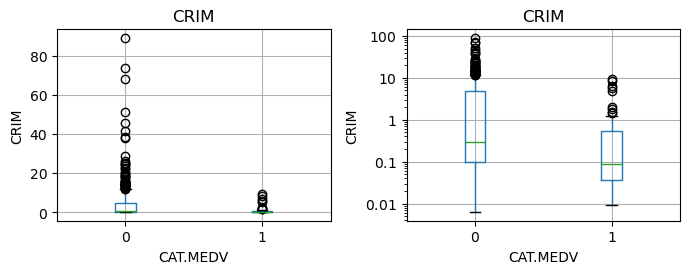

In [101]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 3))

# regular scale
ax = housing_df.boxplot(column='CRIM', by='CAT_MEDV', ax=axes[0])
ax.set_xlabel('CAT.MEDV')
ax.set_ylabel('CRIM')

# log scale
ax = housing_df.boxplot(column='CRIM', by='CAT_MEDV', ax=axes[1])
ax.set_xlabel('CAT.MEDV')
ax.set_ylabel('CRIM')
ax.set_yscale('log')

# suppress the title
axes[0].get_figure().suptitle('')
plt.tight_layout()

plt.show()

## Figure 3.9

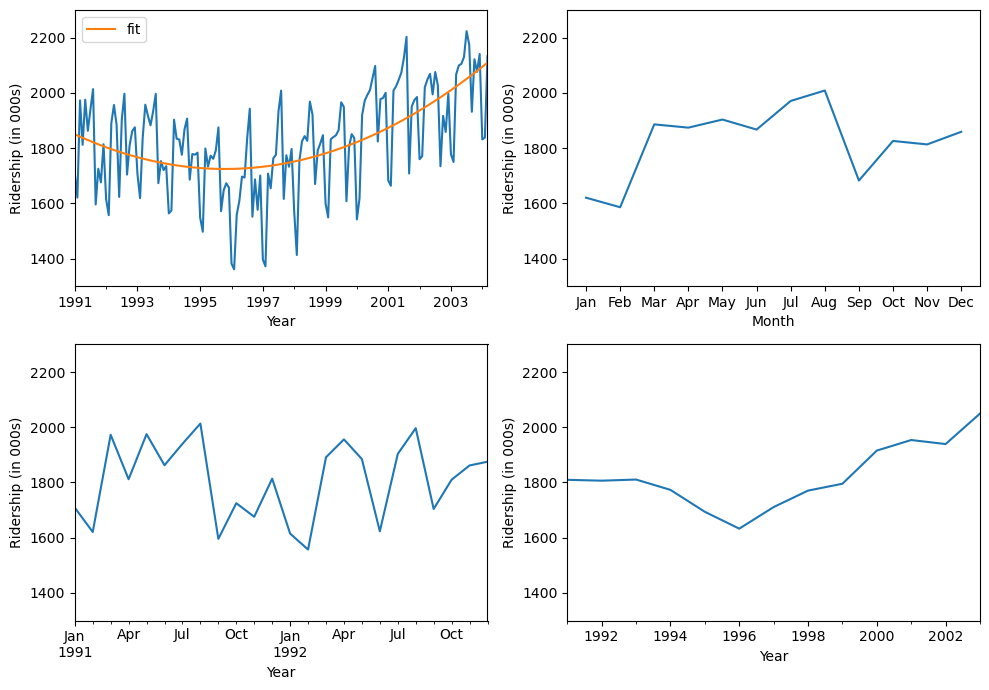

In [104]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 7))


Amtrak_df = pd.read_csv(DATA / 'Amtrak.csv')
Amtrak_df['Month'] = pd.to_datetime(Amtrak_df.Month, format='%d/%m/%Y')
Amtrak_df.set_index('Month', inplace=True)
# inplace: bool, default False, Modify the DataFrame in place (do not create a new object).
# here create a new object.


# fit quadratic curve and display 
quadraticFit = np.poly1d(np.polyfit(range(len(Amtrak_df)), Amtrak_df.Ridership, 2))
Amtrak_fit = pd.DataFrame({'fit': [quadraticFit(t) for t in range(len(Amtrak_df))]})
Amtrak_fit.index = Amtrak_df.index

ax = Amtrak_df.plot(ylim=[1300, 2300], legend=False, ax=axes[0][0])
Amtrak_fit.plot(ax=ax)
ax.set_xlabel('Year')  # set x-axis label
ax.set_ylabel('Ridership (in 000s)')  # set y-axis label

# Zoom in 2-year period 1/1/1991 to 12/1/1992
ridership_2yrs = Amtrak_df.loc['1991-01-01':'1992-12-01']
ax = ridership_2yrs.plot(ylim=[1300, 2300], legend=False, ax=axes[1][0])
ax.set_xlabel('Year')  # set x-axis label
ax.set_ylabel('Ridership (in 000s)')  # set y-axis label

# Average by month
byMonth = Amtrak_df.groupby(by=[Amtrak_df.index.month]).mean()
ax = byMonth.plot(ylim=[1300, 2300], legend=False, ax=axes[0][1])
ax.set_xlabel('Month')  # set x-axis label
ax.set_ylabel('Ridership (in 000s)')  # set y-axis label
# Not sure why this line was here: yticks = [-2.0,-1.75,-1.5,-1.25,-1.0,-0.75,-0.5,-0.25,0.0]
ax.set_xticks(range(1, 13))
ax.set_xticklabels([calendar.month_abbr[i] for i in range(1, 13)]);

# Average by year (exclude data from 2004)
byYear = Amtrak_df.loc['1991-01-01':'2003-12-01'].groupby(pd.Grouper(freq='A')).mean()
ax = byYear.plot(ylim=[1300, 2300], legend=False, ax=axes[1][1])
ax.set_xlabel('Year')  # set x-axis label
ax.set_ylabel('Ridership (in 000s)')  # set y-axis label

plt.tight_layout()

plt.show()

## Figure 3.10

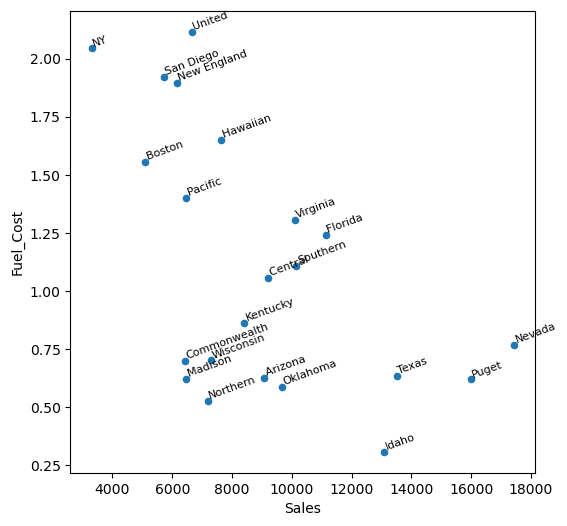

In [107]:
utilities_df = pd.read_csv(DATA / 'Utilities.csv')

ax = utilities_df.plot.scatter(x='Sales', y='Fuel_Cost', figsize=(6, 6))
points = utilities_df[['Sales','Fuel_Cost','Company']]
_ = points.apply(lambda x: 
             ax.text(*x, rotation=20, horizontalalignment='left',
                     verticalalignment='bottom', fontsize=8), axis=1)

# apply function (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.apply.html):
# Run any user-defined function on a DataFrame or Series
# Apply a function either row-wise (axis=1) or column-wise (axis=0) on a DataFrame
# Perform index alignment while applying the function
# Perform aggregation with user-defined functions (however, we usually prefer agg or transform in these cases)
# Perform element-wise transformations
# Broadcast aggregated results to original rows (see the result_type argument).
# Accept positional/keyword arguments to pass to the user-defined functions.

# lambda argument_list: expression
# The argument list consists of a comma separated list of arguments and 
# the expression is an arithmetic expression using these arguments. 
# You can assign the function to a variable to give it a name.
# The following example of a lambda function returns the sum of its two arguments:
# >>> f = lambda x, y : x + y
# >>> f(1,1)
# 2

#  axis=0 is "column-wise" and axis=1 "row-wise".
# It specifies the axis along which the means are computed. By default axis=0. 
# This is consistent with the numpy.mean usage when axis is specified explicitly 
# (in numpy.mean, axis==None by default, which computes the mean value over the 
# flattened array) , in which axis=0 along the rows (namely, index in pandas), 
# and axis=1 along the columns. For added clarity, one may choose to specify 
# axis='index' (instead of axis=0) or axis='columns' (instead of axis=1).

# text() function is used to add text in the Drawing object. 
# It takes x and y coordinates and string that we want to write on (x, y) position.

plt.show()

In [109]:
utilities_df

,Company,Fixed_charge,RoR,Cost,Load_factor,Demand_growth,Sales,Nuclear,Fuel_Cost
0,Arizona,1.06,9.2,151,54.4,1.6,9077,0.0,0.628
1,Boston,0.89,10.3,202,57.9,2.2,5088,25.3,1.555
2,Central,1.43,15.4,113,53.0,3.4,9212,0.0,1.058
3,Commonwealth,1.02,11.2,168,56.0,0.3,6423,34.3,0.700
4,NY,1.49,8.8,192,51.2,1.0,3300,15.6,2.044
5,Florida,1.32,13.5,111,60.0,-2.2,11127,22.5,1.241
6,Hawaiian,1.22,12.2,175,67.6,2.2,7642,0.0,1.652
7,Idaho,1.10,9.2,245,57.0,3.3,13082,0.0,0.309
8,Kentucky,1.34,13.0,168,60.4,7.2,8406,0.0,0.862
9,Madison,1.12,12.4,197,53.0,2.7,6455,39.2,0.623


## Figure 3.11
Use `alpha` to add transparent colors 

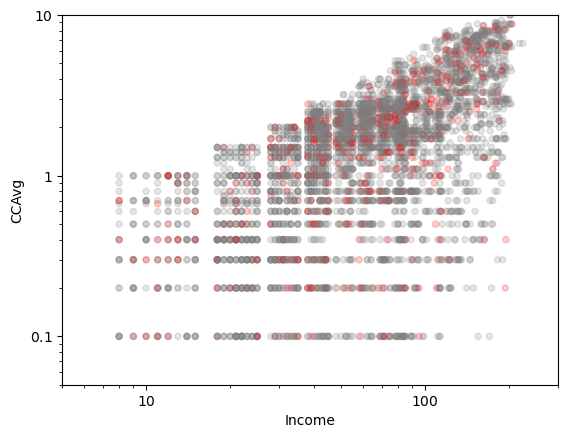

In [112]:
universal_df = pd.read_csv(DATA / 'UniversalBank.csv')

universal_df.plot.scatter(x='Income', y='CCAvg', 
                          c=['red' if c == 1 else 'grey' for c in universal_df['Securities Account']],
                          xlim = (5, 300), ylim = (0.05, 10), alpha=0.2,
                          logx=True, logy=True)
plt.show()

In [114]:
universal_df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


The pandas plot pandas has a number of problems that can be solved using matplotlib 

- overlapping points: add random jitter to the datapoints
- distribution of securities account less obvious due to overplotting: separate plotting of the two sets of accounts

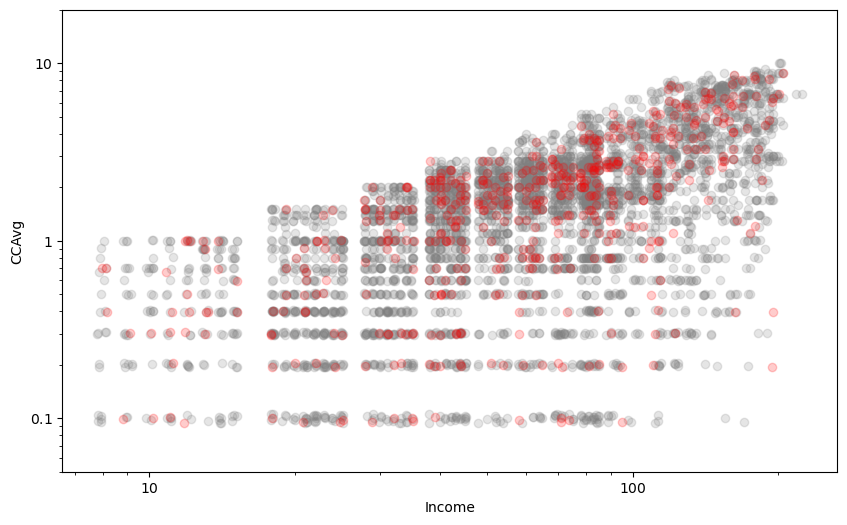

In [118]:
# define a jitter function for use later
# the text within the triple quotes is a docstring, the text that appears 
# when you look up the help documentation about a function.
def jitter(x, factor=1):
    """ Add random jitter to x values """
    sx = np.array(sorted(x))
    delta = sx[1:] - sx[:-1]
    minDelta = min(d for d in delta if d > 0)
    a = factor * minDelta / 5
    return x + np.random.uniform(-a, a, len(x))
  
saIdx = universal_df[universal_df['Securities Account'] == 1].index

plt.figure(figsize=(10,6))
plt.scatter(jitter(universal_df.drop(saIdx).Income),
            jitter(universal_df.drop(saIdx).CCAvg),
            marker='o', color='grey', alpha=0.2)
plt.scatter(jitter(universal_df.loc[saIdx].Income),
            jitter(universal_df.loc[saIdx].CCAvg), 
            marker='o', color='red', alpha=0.2)
plt.xlabel('Income')
plt.ylabel('CCAvg')
plt.ylim((0.05, 20))
# The plt.gca() function gets the current axes so that you can draw on it directly. 
axes = plt.gca()
axes.set_xscale("log")
axes.set_yscale("log")

plt.show()

## Figure 3.12

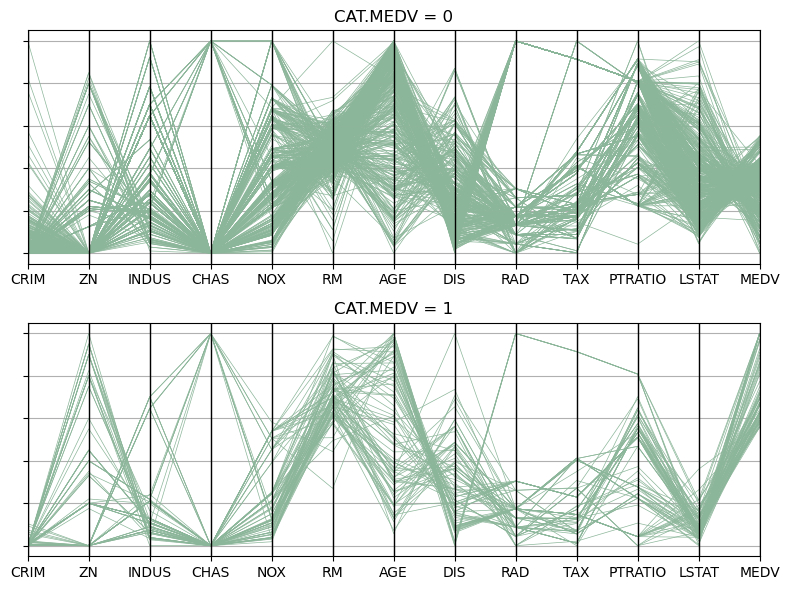

In [121]:
# Transform the axes, so that they all have the same range
min_max_scaler = preprocessing.MinMaxScaler()
dataToPlot = pd.DataFrame(min_max_scaler.fit_transform(housing_df),
                         columns=housing_df.columns)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=[8, 6])
for i in (0, 1):
# see pandas.plotting.parallel_coordinates function at  
# https://pandas.pydata.org/docs/reference/api/pandas.plotting.parallel_coordinates.html
    parallel_coordinates(dataToPlot.loc[dataToPlot.CAT_MEDV == i], 
                         'CAT_MEDV', ax=axes[i], linewidth=0.5)
    axes[i].set_title('CAT.MEDV = {}'.format(i))
    axes[i].set_yticklabels([])
    axes[i].legend().set_visible(False)

plt.tight_layout()  # Increase the separation between the plots

plt.show()

## Figure 3.14

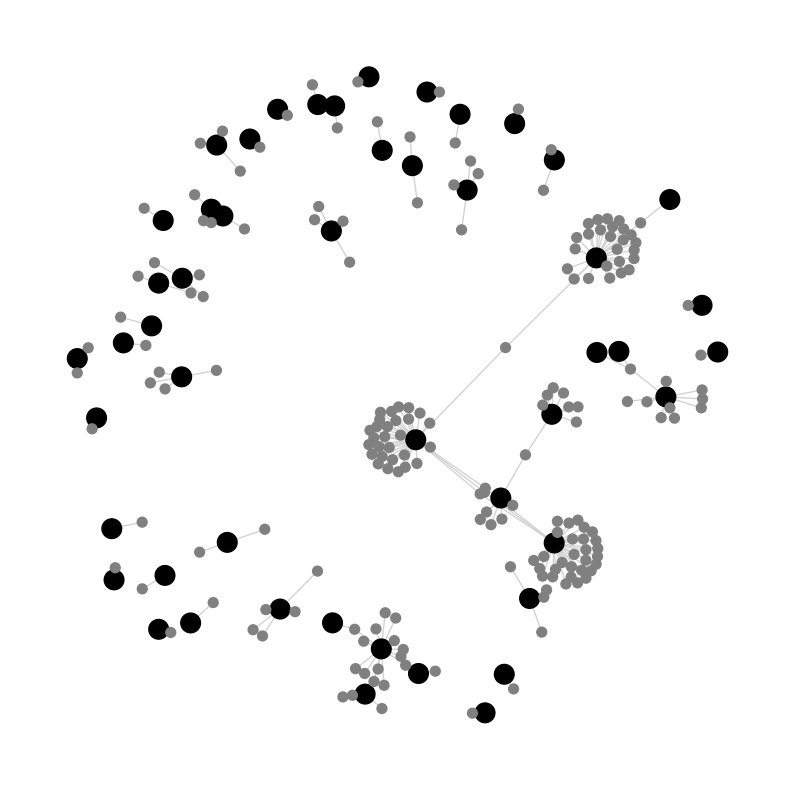

In [124]:
ebay_df = pd.read_csv(DATA / 'eBayNetwork.csv')

G = nx.from_pandas_edgelist(ebay_df, source='Seller', target='Bidder')
# see https://networkx.github.io/documentation/stable/reference/generated/networkx.convert_matrix.from_pandas_edgelist.html
isBidder = [n in set(ebay_df.Bidder) for n in G.nodes()]
pos = nx.spring_layout(G, k=0.13, iterations=60, scale=0.5)
plt.figure(figsize=(10,10))
nx.draw_networkx(G, pos=pos, with_labels=False,
                 edge_color='lightgray',
                 node_color=['gray' if bidder else 'black' for bidder in isBidder],
                 node_size=[50 if bidder else 200 for bidder in isBidder])
# see https://networkx.github.io/documentation/stable/reference/generated/networkx.drawing.nx_pylab.draw_networkx.html
plt.axis('off')

plt.show()

## Figure 3.15
There are currently no packages in Python that provide treemaps of the same quality and flexibility as R. 

Use example from here: https://python-graph-gallery.com/treemap/

In [134]:
#pip install squarify

/var/folders/33/j_slwxmx51n1p5p7bj0xq8sh0000gq/T/ipykernel_33780/3781928835.py:7: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for category, df in ebayTreemap.groupby(['Category']):


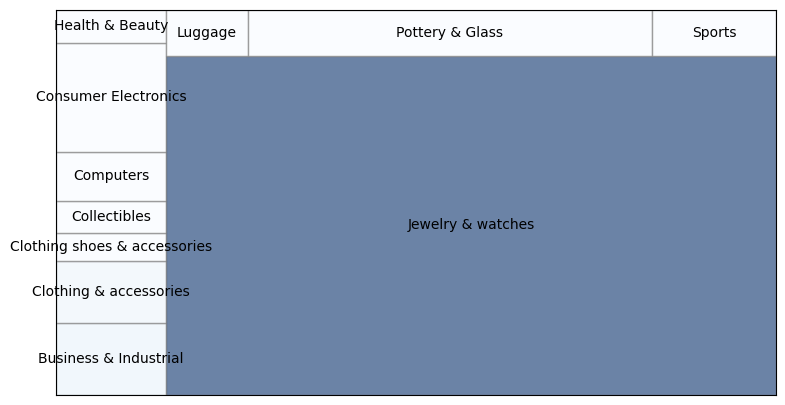

In [136]:
import squarify
import matplotlib

ebayTreemap = pd.read_csv(DATA/ 'EbayTreemap.csv')

grouped = []
for category, df in ebayTreemap.groupby(['Category']):
    negativeFeedback = sum(df['Seller Feedback'] < 0) / len(df)
    grouped.append({
        'category': category, 
        'negativeFeedback': negativeFeedback, 
        'averageBid': df['High Bid'].mean()
    })
byCategory = pd.DataFrame(grouped)

norm = matplotlib.colors.Normalize(vmin=byCategory.negativeFeedback.min(), vmax=byCategory.negativeFeedback.max())
colors = [matplotlib.cm.Blues(norm(value)) for value in byCategory.negativeFeedback]

fig, ax = plt.subplots()
fig.set_size_inches(9, 5)

squarify.plot(label=byCategory.category, sizes=byCategory.averageBid, color=colors, 
              ax=ax, alpha=0.6, edgecolor='grey')
# Pure Python implementation of the squarify treemap layout algorithm https://github.com/laserson/squarify
# https://en.wikipedia.org/wiki/Treemapping
ax.get_xaxis().set_ticks([])
ax.get_yaxis().set_ticks([])

plt.subplots_adjust(left=0.1)
plt.show()

## Figure 3.16
To run this example you need an API key for Google maps. Go to https://cloud.google.com/maps-platform/ to find out how to getone

## Figure 3.17
<div class="alert alert-info">If you get an error message on MacOS about a missing library, set the environment variable `DYLD_FALLBACK_LIBRARY_PATH` before starting jupyter notebook.
<br>
```
export DYLD_FALLBACK_LIBRARY_PATH=/usr/local/lib:/lib:/usr/lib
```
</div>

## Due to the Anaconda version we had to install, "cartopy" cannot be installed. Skip from here. 

In [158]:
# pip install cartopy

In [152]:
# installed cartopy in Terminal on Mac: conda install -c conda-forge cartopy
import matplotlib
import matplotlib.pyplot as plt
import cartopy
import cartopy.io.shapereader as shpreader
import cartopy.crs as ccrs

In [154]:
gdp_df = pd.read_csv(DATA / 'gdp.csv', skiprows=4)
gdp_df.rename(columns={'2015': 'GDP2015'}, inplace=True)
gdp_df.set_index('Country Code', inplace=True)  # use the three letter country code to access rows

# The file contains a column with two letter combinations, use na_filter to avoid converting
# the combination NA into not-a-number
happiness_df = pd.read_csv(DATA / 'Veerhoven.csv', na_filter = False)
happiness_df.set_index('Code', inplace=True)  # use the country name to access rows

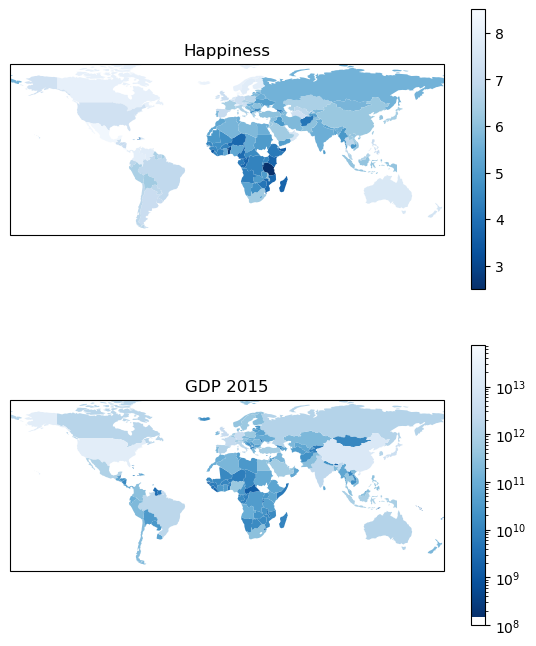

In [156]:
fig = plt.figure(figsize=(7, 8))

ax1 = plt.subplot(2, 1, 1, projection=ccrs.PlateCarree())
ax1.set_extent([-150, 60, -25, 60])

ax2 = plt.subplot(2, 1, 2, projection=ccrs.PlateCarree())
ax2.set_extent([-150, 60, -25, 60])

# Create a color mapper
cmap = plt.cm.Blues_r
norm1 = matplotlib.colors.Normalize(vmin=happiness_df.Score.dropna().min(), 
                                    vmax=happiness_df.Score.dropna().max())
norm2 = matplotlib.colors.LogNorm(vmin=gdp_df.GDP2015.dropna().min(), 
                                  vmax=gdp_df.GDP2015.dropna().max())

shpfilename = shpreader.natural_earth(resolution='110m',
                                      category='cultural',
                                      name='admin_0_countries')
reader = shpreader.Reader(shpfilename)
countries = reader.records()
for country in countries:
    countryCode = country.attributes['ADM0_A3']
    if countryCode in gdp_df.index:
        ax2.add_geometries(country.geometry, ccrs.PlateCarree(),
                           facecolor=cmap(norm2(gdp_df.loc[countryCode].GDP2015)))
    # check various attributes to find the matching two-letter combinations
    nation = country.attributes['POSTAL'] 
    if nation not in happiness_df.index:
        nation = country.attributes['ISO_A2']
    if nation not in happiness_df.index:
        nation = country.attributes['WB_A2']
    if nation not in happiness_df.index and country.attributes['NAME'] == 'Norway':
        nation = 'NO'
    if nation in happiness_df.index:
        ax1.add_geometries(country.geometry, ccrs.PlateCarree(),
                           facecolor=cmap(norm1(happiness_df.loc[nation].Score)))
        
ax2.set_title("GDP 2015")
sm = plt.cm.ScalarMappable(norm=norm2, cmap=cmap)
sm._A = []
cb = plt.colorbar(sm, ax=ax2)
cb.set_ticks([1e8, 1e9, 1e10, 1e11, 1e12, 1e13])

ax1.set_title("Happiness")
sm = plt.cm.ScalarMappable(norm=norm1, cmap=cmap)
sm._A = []
cb = plt.colorbar(sm, ax=ax1)
cb.set_ticks([3, 4, 5, 6, 7, 8])


plt.show()

In [160]:
import matplotlib
import matplotlib.pyplot as plt
import cartopy
import cartopy.io.shapereader as shpreader
import cartopy.crs as ccrs

In [162]:
gdp_df = pd.read_csv(DATA / 'gdp.csv')

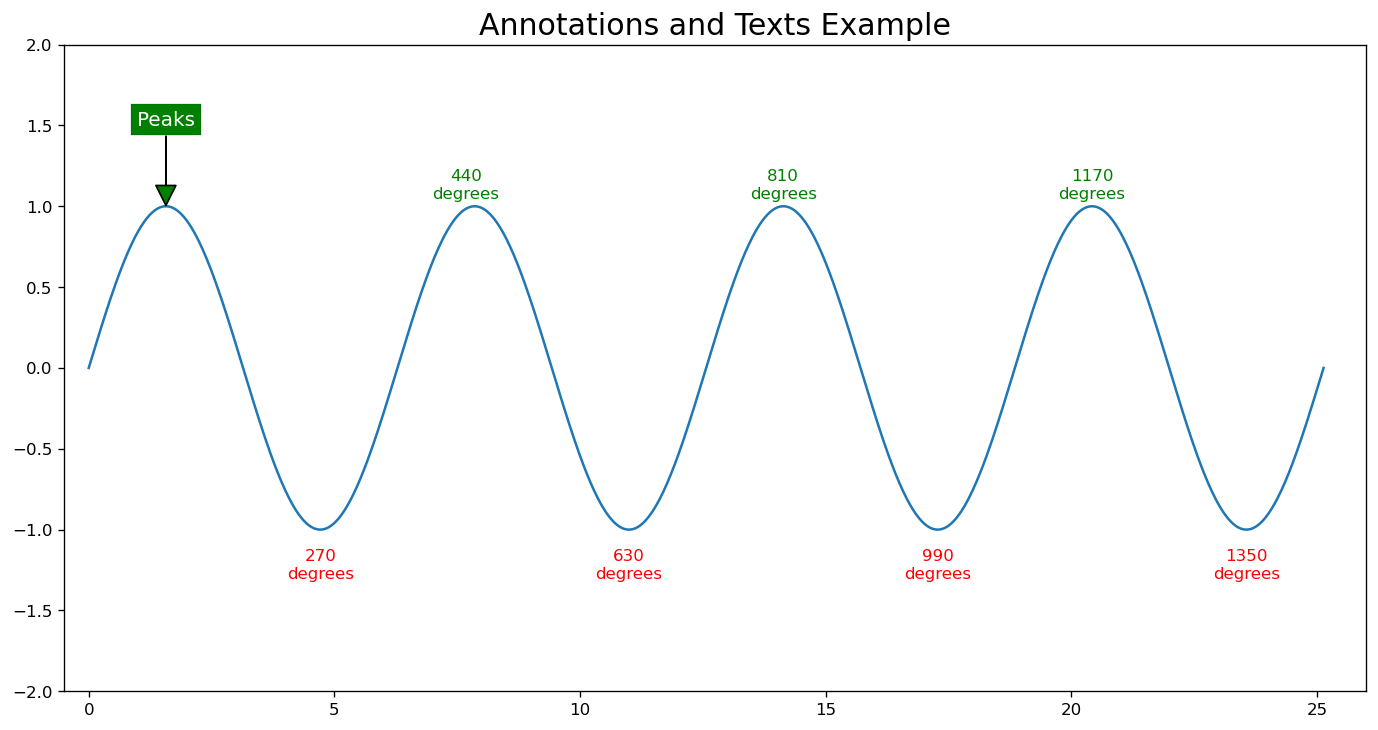

In [164]:
# Texts, Arrows and Annotations Example
# ref: https://matplotlib.org/users/annotations_guide.html
plt.figure(figsize=(14,7), dpi=120)
X = np.linspace(0, 8*np.pi, 1000)
sine = plt.plot(X,np.sin(X), color='tab:blue');

# 1. Annotate with Arrow Props and bbox
plt.annotate('Peaks', xy=(90/57.2985, 1.0), xytext=(90/57.2985, 1.5),
             bbox=dict(boxstyle='square', fc='green', linewidth=0.1),
             arrowprops=dict(facecolor='green', shrink=0.01, width=0.1), 
             fontsize=12, color='white', horizontalalignment='center')
for angle in [440, 810, 1170]:
    plt.text(angle/57.2985, 1.05, str(angle) + "\ndegrees", transform=plt.gca().transData, horizontalalignment='center', color='green')

for angle in [270, 630, 990, 1350]:
    plt.text(angle/57.2985, -1.3, str(angle) + "\ndegrees", transform=plt.gca().transData, horizontalalignment='center', color='red')    

plt.gca().set(ylim=(-2.0, 2.0), xlim=(-.5, 26))
plt.title('Annotations and Texts Example', fontsize=18)
plt.show()

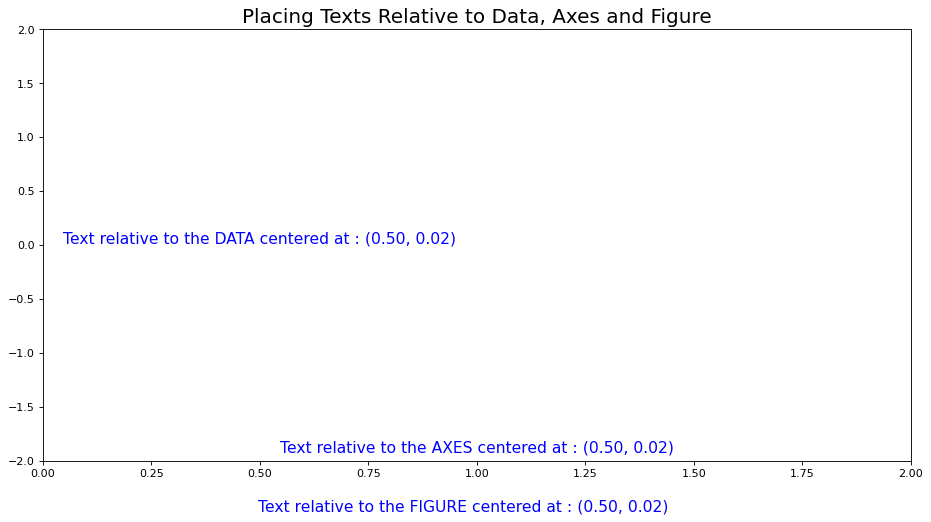

In [166]:
# Texts, Arrows and Annotations Example
plt.figure(figsize=(14,7), dpi=80)
X = np.linspace(0, 8*np.pi, 1000)

# Text Relative to DATA
plt.text(0.50, 0.02, "Text relative to the DATA centered at : (0.50, 0.02)", transform=plt.gca().transData, fontsize=14, ha='center', color='blue')

# Text Relative to AXES
plt.text(0.50, 0.02, "Text relative to the AXES centered at : (0.50, 0.02)", transform=plt.gca().transAxes, fontsize=14, ha='center', color='blue')

# Text Relative to FIGURE
plt.text(0.50, 0.02, "Text relative to the FIGURE centered at : (0.50, 0.02)", transform=plt.gcf().transFigure, fontsize=14, ha='center', color='blue')

plt.gca().set(ylim=(-2.0, 2.0), xlim=(0, 2))
plt.title('Placing Texts Relative to Data, Axes and Figure', fontsize=18)
plt.show()

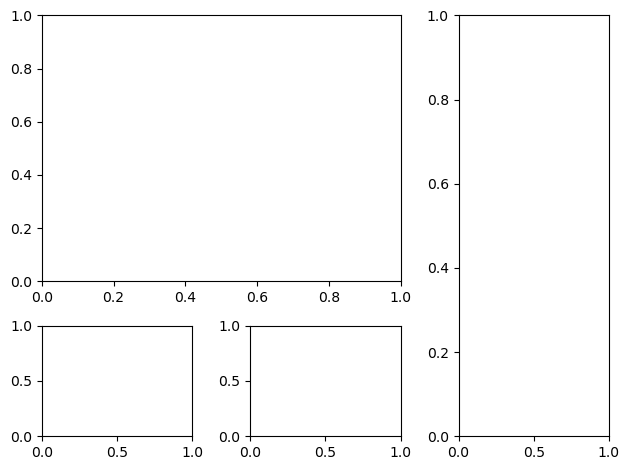

In [168]:
fig = plt.figure()
ax1 = plt.subplot2grid((3,3), (0,0), colspan=2, rowspan=2) # topleft
ax3 = plt.subplot2grid((3,3), (0,2), rowspan=3)            # right
ax4 = plt.subplot2grid((3,3), (2,0))                       # bottom left
ax5 = plt.subplot2grid((3,3), (2,1))                       # bottom right
fig.tight_layout()

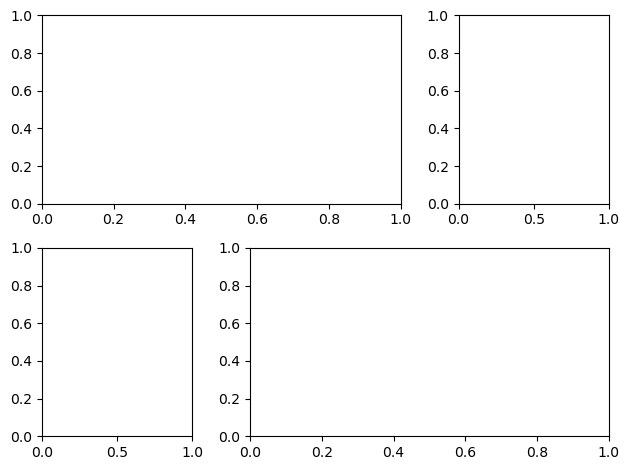

In [170]:
# GridSpec Approach 1
import matplotlib.gridspec as gridspec
fig = plt.figure()
grid = plt.GridSpec(2, 3)  # 2 rows 3 cols
plt.subplot(grid[0, :2])  # top left
plt.subplot(grid[0, 2])   # top right
plt.subplot(grid[1, :1])  # bottom left
plt.subplot(grid[1, 1:])  # bottom right
fig.tight_layout()

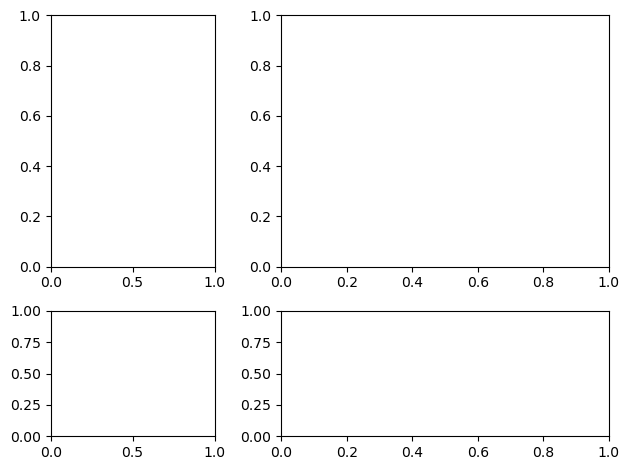

In [172]:
import matplotlib.gridspec as gridspec
fig = plt.figure()
gs = gridspec.GridSpec(2, 2, height_ratios=[2,1], width_ratios=[1,2])
for g in gs:
    ax = fig.add_subplot(g)    
fig.tight_layout()

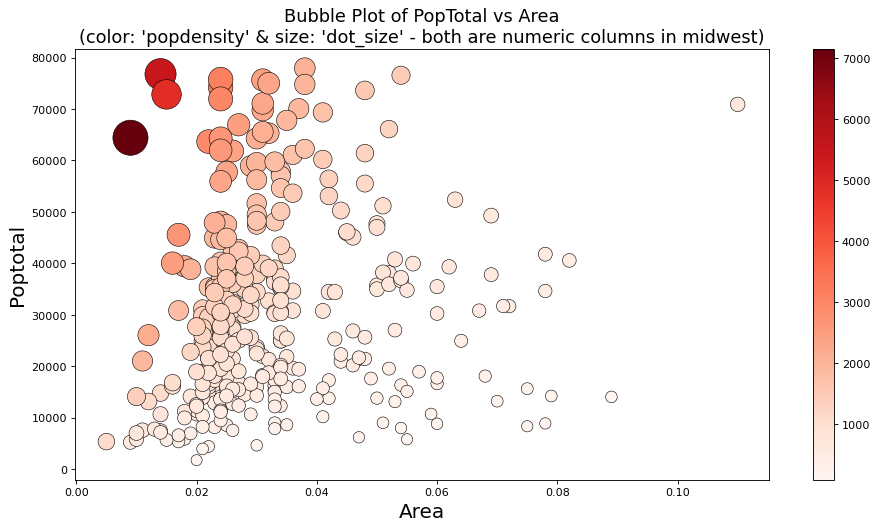

In [174]:
# Scatterplot with varying size and color of points
import pandas as pd
midwest = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/midwest_filter.csv")

# Plot
fig = plt.figure(figsize=(14, 7), dpi= 80, facecolor='w', edgecolor='k')    
plt.scatter('area', 'poptotal', data=midwest, s='dot_size', c='popdensity', cmap='Reds', edgecolors='black', linewidths=.5)
plt.title("Bubble Plot of PopTotal vs Area\n(color: 'popdensity' & size: 'dot_size' - both are numeric columns in midwest)", fontsize=16)
plt.xlabel('Area', fontsize=18)
plt.ylabel('Poptotal', fontsize=18)
plt.colorbar()
plt.savefig("bubbleplot2.png", transparent=True, dpi=120)

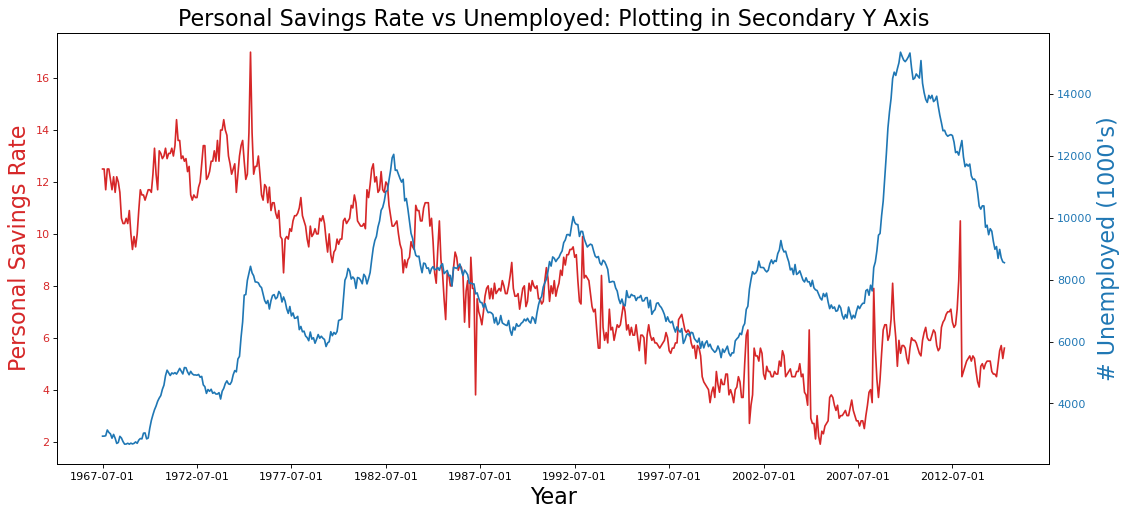

In [178]:
# Import Data
df = pd.read_csv("https://github.com/selva86/datasets/raw/master/economics.csv")
x = df['date']; y1 = df['psavert']; y2 = df['unemploy']

# Plot Line1 (Left Y Axis)
fig, ax1 = plt.subplots(1,1,figsize=(16,7), dpi= 80)
ax1.plot(x, y1, color='tab:red')

# Plot Line2 (Right Y Axis)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
ax2.plot(x, y2, color='tab:blue')

# Just Decorations!! -------------------
# ax1 (left y axis)
ax1.set_xlabel('Year', fontsize=20)
ax1.set_ylabel('Personal Savings Rate', color='tab:red', fontsize=20)
ax1.tick_params(axis='y', rotation=0, labelcolor='tab:red' )

# ax2 (right Y axis)
ax2.set_ylabel("# Unemployed (1000's)", color='tab:blue', fontsize=20)
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.set_title("Personal Savings Rate vs Unemployed: Plotting in Secondary Y Axis", fontsize=20)
ax2.set_xticks(np.arange(0, len(x), 60))
ax2.set_xticklabels(x[::60], rotation=90, fontdict={'fontsize':10})
plt.show()

In [180]:
# use "def" to define a function and write "apply" statements
def my_exp(x, e):
    return x**e

In [182]:
cb=my_exp(2,3)
print(cb)

8


In [184]:
import pandas as pd
df=pd.DataFrame({'a': [10, 20, 30], 'b':[20,30,40]})
print(df)

    a   b
0  10  20
1  20  30
2  30  40


In [186]:
print(df['a']**2)

0    100
1    400
2    900
Name: a, dtype: int64


In [188]:
ex=df['b'].apply(my_exp, e=2)
print(ex)

0     400
1     900
2    1600
Name: b, dtype: int64


In [190]:
ex=df['a'].apply(my_exp,e=3)
print(ex)

0     1000
1     8000
2    27000
Name: a, dtype: int64


In [192]:
def print_me(x):
    print(x)

In [194]:
print(df['a'])

0    10
1    20
2    30
Name: a, dtype: int64


In [196]:
df.apply(print_me, axis=0)

0    10
1    20
2    30
Name: a, dtype: int64
0    20
1    30
2    40
Name: b, dtype: int64


a    None
b    None
dtype: object

In [198]:
df.apply(print_me, axis=1)

a    10
b    20
Name: 0, dtype: int64
a    20
b    30
Name: 1, dtype: int64
a    30
b    40
Name: 2, dtype: int64


0    None
1    None
2    None
dtype: object

In [200]:
print(df['a'])

0    10
1    20
2    30
Name: a, dtype: int64


In [202]:
print(df['b'])

0    20
1    30
2    40
Name: b, dtype: int64


In [204]:
# Column-wise Operations finding column averages
def avg_3_apply(col):
    x=col[0]
    y=col[1]
    z=col[2]
    return (x+y+z)/3

In [206]:
print(df.apply(avg_3_apply))

a    20.0
b    30.0
dtype: float64


In [208]:
# Row-wise Operations
def avg_2_apply(row):
    x=row[0]
    y=row[1]
    return (x+y)/2
print(df.apply(avg_2_apply, axis=0))

a    15.0
b    25.0
dtype: float64


In [210]:
# Column-wise Operations finding row averages
def avg_2_apply(col):
    x=col[0]
    y=col[1]
    return (x+y)/2
print(df.apply(avg_2_apply, axis=1))

0    15.0
1    25.0
2    35.0
dtype: float64


In [212]:
print(df.mean(axis=1))

0    15.0
1    25.0
2    35.0
dtype: float64


In [214]:
# Vectorized Functions
def avg_2(x, y):
    return (x + y) / 2

In [216]:
df

,a,b
0,10,20
1,20,30
2,30,40


In [218]:
avg_2(df['a'], df['b'])

0    15.0
1    25.0
2    35.0
dtype: float64

In [220]:
(df['a'] + df['b']) / 2

0    15.0
1    25.0
2    35.0
dtype: float64

In [228]:
def avg_2_mod(x, y):
    if (x == 20):
        return np.NaN
    else:
        return (x + y) / 2

In [234]:
#avg_2_mod(df['a'], df['b'])

In [236]:
avg_2_mod(20, 30)

nan

In [238]:
import numpy as np
# np.vectorize creates a new function
avg_2_mod_vec = np.vectorize(avg_2_mod)
df

,a,b
0,10,20
1,20,30
2,30,40


In [240]:
avg_2_mod_vec(df['a'], df['b'])

array([15., nan, 35.])

In [242]:
@np.vectorize
def v_avg_2_mod(x, y):
    if (x == 20):
        return np.NaN
    else:
        return (x + y) / 2

In [244]:
v_avg_2_mod(df['a'], df['b'])

array([15., nan, 35.])

In [246]:
# numba optimize Python code, especially calculations on arrays performing mathematical functions.
# see http://numba.pydata.org/
import numba
@numba.vectorize
def v_avg_2_mod_numba(x, y):
    if (x == 20):
        return np.NaN
    else:
        return (x + y) / 2
v_avg_2_mod_numba(df['a'].values, df['b'].values)

array([15., nan, 35.])

In [247]:
# If the function used in the apply method is simple enough, we can use lambda function for small one-liner calculations.
# See an example in the code for Figure 3.10 above

In [248]:
import seaborn as sns
titanic=sns.load_dataset("titanic")
print(titanic.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


In [252]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [254]:
def count_missing(vec):
    """Counts the number of missing values in a vector
    """
    null_vec = pd.isnull(vec)
    null_count = np.sum(null_vec)
    return null_count

In [256]:
count_missing?

Signature: count_missing(vec)
Docstring:
Counts the number of missing values in a vector
    
File:      /var/folders/33/j_slwxmx51n1p5p7bj0xq8sh0000gq/T/ipykernel_33780/3590789969.py
Type:      function

In [258]:
import numpy as np
cmis_col = titanic.apply(count_missing, axis=0)

In [260]:
cmis_col

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [262]:
cmis_row = titanic.apply(count_missing, axis=1)

In [264]:
cmis_row

0      1
1      0
2      1
3      0
4      1
      ..
886    1
887    0
888    2
889    0
890    1
Length: 891, dtype: int64

In [266]:
universal_df = pd.read_csv(DATA / 'UniversalBank.csv')

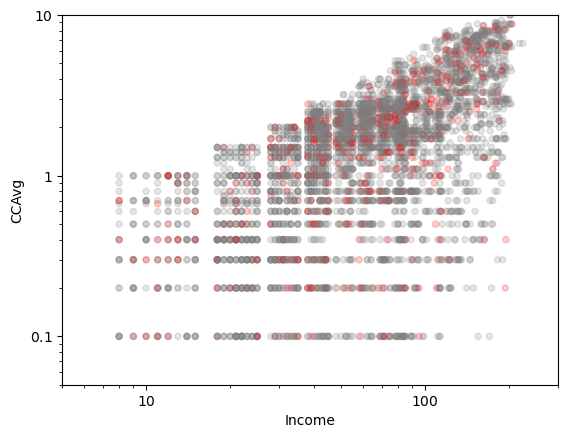

In [268]:
universal_df.plot.scatter(x='Income', y='CCAvg', 
                          c=['red' if c == 1 else 'grey' for c in universal_df['Securities Account']],
                          xlim = (5, 300), ylim = (0.05, 10), alpha=0.2,
                          logx=True, logy=True)
plt.show()

In [270]:
universal_df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
